In [1]:
%cd ..

/home/mat/dev/cached_dilated_causal_convolutions


/home/mat/dev/cached_dilated_causal_convolutions/.venv/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
import warnings
warnings.simplefilter(action="ignore", category=FutureWarning)

import pandas as pd
import zarr
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

from common.sample_db import SampleDB

db = SampleDB()

### distributiuon of losses from score

In [3]:
SOBOL_RUN = "006"

SCORE_MODEL_IS_RUNS = [
    ('232_keras/i0', "210"),
]

BETA_STFT = 0.01

In [4]:
dfs = []

for score_model, is_run in SCORE_MODEL_IS_RUNS:

    losses = db.losses_for(run=SOBOL_RUN, model=score_model)
    df = pd.DataFrame(losses)
    df['run'] = SOBOL_RUN
    df['score_model'] = score_model
    df['src'] = 'sobol'
    dfs.append(df)

    if is_run is not None:
        losses = db.losses_for(run=is_run, model=score_model)
        df = pd.DataFrame(losses)
        df['run'] = is_run
        df['score_model'] = score_model
        df['src'] = 'hard_mined'
        dfs.append(df)

losses_df = pd.concat(dfs)
losses_df.head()
#losses_1_df['src'] = 'sobol'
#losses_1_df.describe()

,idx,loss,huber,stft,run,score_model,src
0,0,0.074241,0.006028,0.682123,006,232_keras/i0,sobol
1,1,0.120909,0.003368,1.175410,006,232_keras/i0,sobol
2,2,0.120673,0.003132,1.175412,006,232_keras/i0,sobol
3,3,0.079763,0.019610,0.601533,006,232_keras/i0,sobol
4,4,0.078788,0.012692,0.660968,006,232_keras/i0,sobol


In [7]:
losses_df.score_model.unique(), losses_df.run.unique()

(array(['232_keras/i0'], dtype=object), array(['006', '210'], dtype=object))

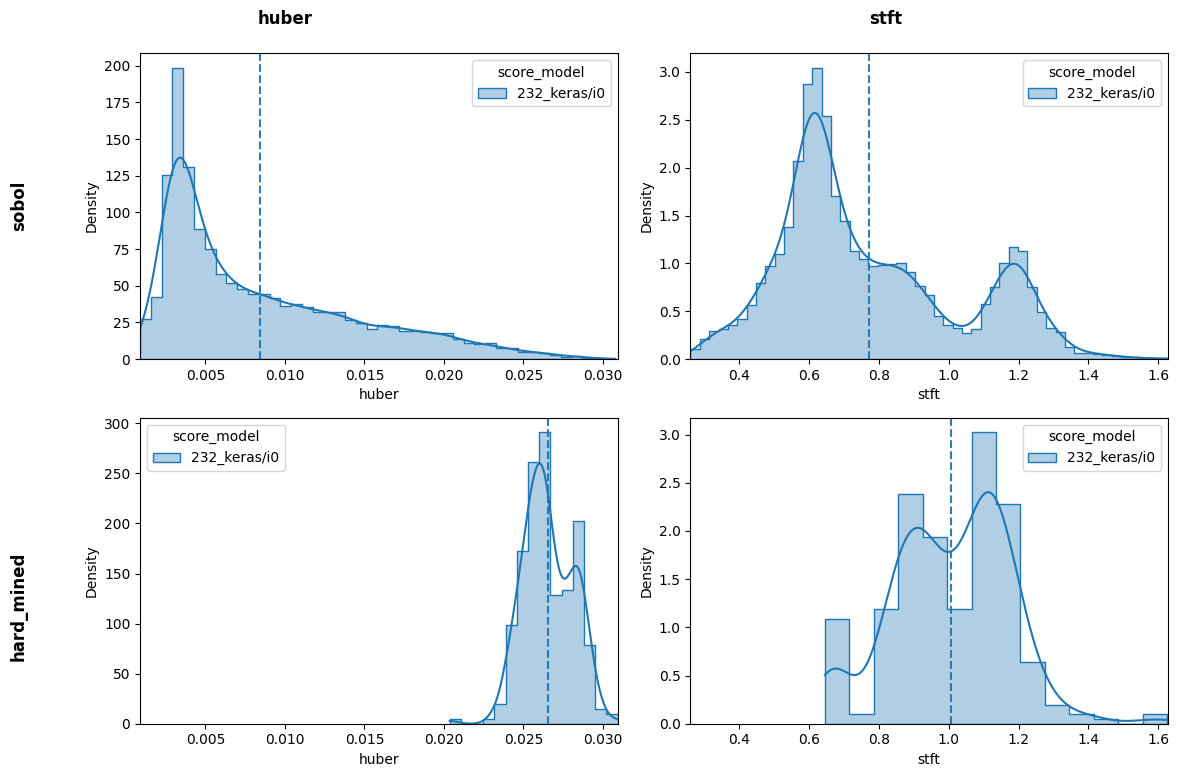

In [6]:
src_values = ['sobol', 'hard_mined']
cols = ['huber', 'stft']
score_models = sorted(losses_df['score_model'].unique())

# Keep histogram and mean-line colors aligned across all subplots.
palette = sns.color_palette(n_colors=len(score_models))
palette_map = dict(zip(score_models, palette))

shared_xlim = {
    col: (losses_df[col].min(), losses_df[col].max())
    for col in cols
}

fig, axes = plt.subplots(len(src_values), len(cols), figsize=(12, 4 * len(src_values)), squeeze=False)

for row, src in enumerate(src_values):
    subset = losses_df[losses_df['src'] == src]
    for col_idx, col in enumerate(cols):
        ax = axes[row, col_idx]
        sns.histplot(
            data=subset,
            x=col,
            hue='score_model',
            hue_order=score_models,
            palette=palette_map,
            kde=True,
            stat='density',
            common_norm=False,
            alpha=0.35,
            element='step',
            ax=ax,
        )

        # Mean marker per score model in matching hue color.
        for model in score_models:
            model_vals = subset.loc[subset['score_model'] == model, col].dropna()
            if not model_vals.empty:
                ax.axvline(
                    model_vals.mean(),
                    color=palette_map[model],
                    linestyle='--',
                    linewidth=1.5,
                    alpha=0.95,
                )

        ax.set_xlim(shared_xlim[col])

# Column labels (top)
for col_idx, col in enumerate(cols):
    x = (col_idx + 0.5) / len(cols)
    fig.text(x, 0.995, col, ha='center', va='top', fontsize=12, fontweight='bold')

# Row labels (left, vertical)
for row, src in enumerate(src_values):
    y = 1 - ((row + 0.5) / len(src_values))
    fig.text(0.028, y, src, ha='center', va='center', rotation=90, fontsize=12, fontweight='bold')

plt.tight_layout(rect=(0.07, 0.03, 1.0, 0.96))
plt.show()